# Statistics - Lab 2

> **Deadline**: One week from your lab session. Check precise deadline for your group in AG.  

**Submission Guidelines**:
- Submit your work as a Jupyter Notebook file (`Lab2.ipynb`) via the Aula Global platform
- Include your dataset file in the submission
- Compress both files (`Lab2.ipynb` and your dataset) into a single `.zip` file
- Upload only the `.zip` file to Aula Global

Your submission should include:
- All code with appropriate comments
- All visualizations
- Written explanations and interpretations
- The dataset used in your analysis

**Important Notes**:
- Your code must be designed to work with any compatible dataset file
- Separate files (`.docx`, `.pdf`, or standalone figures) will not be accepted
- To ensure reproducibility, test your notebook with different datasets
- If the code fails to execute, your submission will be graded as **0**.
- There are some cells with code. **You're not allowed to modify the code in these cells**. Your code needs to be compatible with these cells, i.e. they need to run without errors.

Libraries imports to be used through the whole Lab:

In [83]:
import statistics
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy

## Question 1

> Maximum score: *2.5 points*

Search for a dataset suitable for multiple linear regression analysis and prepare it according to the following specifications:

### Dataset Selection Criteria:
- Choose an interesting/fun example suitable for presentation (you can find datasets on repositories like [Kaggle](https://www.kaggle.com/datasets) or [Google Dataset Search](https://datasetsearch.research.google.com/), or any other reliable source you prefer)
- Dataset should be appropriate for multiple linear regression
- Consider examples that could lead to meaningful insights
- Take time to find an interesting example; If you don't find a good example within 30 min, proceed with a temporary dataset and continue with other questions - you can find a better dataset later at home

### Dataset Requirements:
1. **Variables**:
  - Two regressors ($x_1$ and $x_2$)
  - One response variable ($y$)

2. **Sample Size**:
  - Minimum: 100 observations
  - Maximum: Should be reasonable to avoid computational overhead. If the downloaded dataset is too large, take a smaller random sample.

### Data Preparation:
1. Create a matrix `D` with three columns in the following order:
  - Column 1: $x_1$ (first regressor)
  - Column 2: $x_2$ (second regressor)
  - Column 3: $y$ (response variable)

2. The matrix should be stored as a 2D NumPy array with shape $(N,3)$, where $N$ is the number of observations.
3. Save the matrix as `dataset.npy` using NumPy's save function.

**Important**: Incorrect data format will result in a grade of 0.

*Hints:*
* Kaggle datasets provide Python code that can be used to download the dataset (check "Download" button).
* The datasets are stored as a table with named columns. A common format to store tables is as `.csv` files, which stands for comma separated values. It is just a text file, where each line contains a row in the table and the values in the row are separated by commas.
* The standard Python library to process tables is Pandas. Pandas stores tables in a data type called `DataFrame`. These are some useful Pandas functions:


In [84]:
# Note: this cell provides an error if you run it because the variable
# 'path_to_csv_file' has not been defined. It is only given here to
# show how to use pandas.

# Open dataset from a CSV file and returns a Pandas DataFrame
data = pd.read_csv("fitness_data.csv")

# Shuffle the dataset
data = data.sample(frac=1).reset_index(drop=True)

# Take 300 data rows
data = data.iloc[:300]

# Show header and first 5 rows
data.head()

# Extract list of values for a column
col_vals = data["Duration"].values

## Solution to Question 1

In [85]:
# WRITE YOUR SOLUTION HERE
x1 = data["Duration"].values #regressor 1, duration of workout
x2 = data["Heart_Rate"].values #regressor 2, heart rate
y  = data["Calories"].values #response, total calories

D = np.column_stack((x1, x2, y)) #array shaped as (N,3)

np.save('content/dataset.npy', D) #save the dataset in external file

data.head()

,Duration,Heart_Rate,Calories
0,16.0,99.0,91.0
1,26.0,110.0,185.0
2,27.0,111.0,185.0
3,19.0,97.0,114.0
4,21.0,98.0,116.0


## Question 2

> Maximum score: *2.0 points*

Obtain the least squares fit for $y$ using the regressors $x_1$ and $x_2$, following the methods discussed in class. You can use NumPy for matrix multiplication, and matrix inversion, but you cannot use libraries for least squares fitting.

Plot the data points in 3D space using `matplotlib.pyplot` (as documented [here](https://matplotlib.org/stable/gallery/mplot3d/scatter3d.html)). Finally, plot the fitted regression plane on top of the scatter plot using the [`np.meshgrid()`](https://numpy.org/doc/stable/reference/generated/numpy.meshgrid.html) and [`plot_surface()`](https://matplotlib.org/stable/api/_as_gen/mpl_toolkits.mplot3d.axes3d.Axes3D.plot_surface.html#mpl_toolkits.mplot3d.axes3d.Axes3D.plot_surface) functions.

In [86]:
# Import the saved dataset -> this will allow us to test the workflow with their preprocessed data
D = np.load("content/dataset.npy")

# Split data matrix into X (predictors) and y (response)
X = D[:, :2]  # predictors
y = D[:, 2]   # respose

## Solution to Question 2

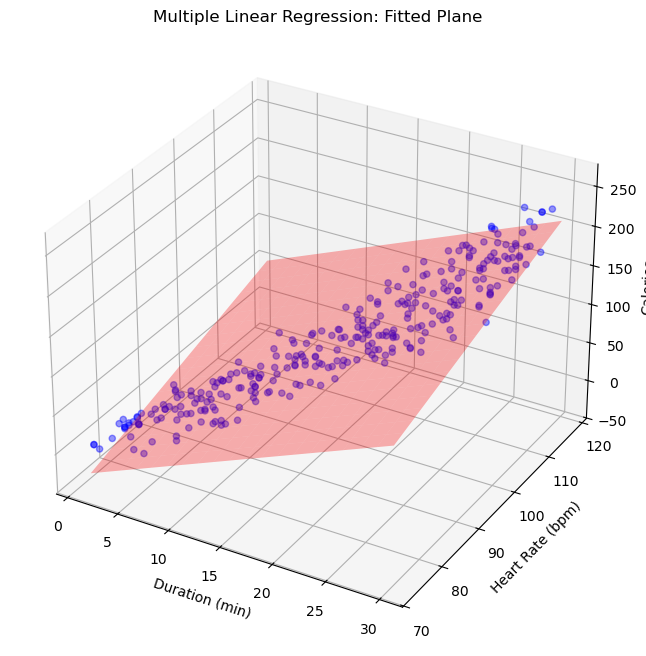

In [87]:
# WRITE YOUR SOLUTION HERE
#We need to find y = b0+b1x1+b2x2 = X*b

#Multilinear least squares
# Beta = (X^T * X)^-1 * X^T * y

#we start adding 1 column at left of x
N_ones= X.shape[0]
ones_col = np.ones(N_ones)
X_mod = np.column_stack((ones_col, X)) #row is the data iteration, column defines the regression variable

#np.transpose
#np.linalg.inv
#np.dot
x_t = np.transpose(X_mod)
prod1 = np.dot (x_t, X_mod)
prod1_inv= np.linalg.inv(prod1) #(XT*X)-1
prod2 = np.dot(prod1_inv,x_t)
beta_custom= np.dot(prod2, y) #we estimate beta, that will result into having three positions


x1_range = np.linspace(X[:, 0].min(), X[:, 0].max(), 20) #define range of calues, separated by 20
x2_range = np.linspace(X[:, 1].min(), X[:, 1].max(), 20)
X1_mesh, X2_mesh = np.meshgrid(x1_range, x2_range) #create the coord grid containing all values possible of x1 x2

Z = beta_custom[0] + beta_custom[1] * X1_mesh + beta_custom[2] * X2_mesh #regression eq response for each x1 x2


fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(projection='3d')

ax.scatter(X[:, 0], X[:, 1], y, color='blue', alpha=0.4, label='Data Points') #plot actual observations

surf = ax.plot_surface(X1_mesh, X2_mesh, Z, color='red', alpha=0.3) #plot the regression values for each x1 and x2 values approx

ax.set_xlabel('Duration (min)')
ax.set_ylabel('Heart Rate (bpm)')
ax.set_zlabel('Calories')
ax.set_title('Multiple Linear Regression: Fitted Plane')

plt.show()


In [88]:
# THIS CODE HAS TO RUN WITHOUT ANY MODIFICATION
print("Custom Implementation:")
print("Intercept:", beta_custom[0])
print("Slope 1:", beta_custom[1])
print("Slope 2:", beta_custom[2])

Custom Implementation:
Intercept: -175.93414124110825
Slope 1: 5.366193789497658
Slope 2: 1.927902223207833


## Question 3

> Maximum score: *0.5 points*

Compare the results of Question 2 with those obtained with a libraries for least squares fitting. You can use `statsmodel` function `OLS` or `scikit-learn` function `LinearRegression`.

## Solution to Question 3

In [89]:
# WRITE YOUR SOLUTION HERE
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X, y) #fit X matrix regressors and Y matrix response
beta_library = np.array([model.intercept_, model.coef_[0], model.coef_[1]])


In [90]:
# THIS CODE HAS TO RUN WITHOUT ANY MODIFICATION
print("Library Implementation:")
print("Intercept:", beta_library[0])
print("Slope 1:", beta_library[1])
print("Slope 2:", beta_library[2])

print("Custom Implementation:")
print("Intercept:", beta_custom[0])
print("Slope 1:", beta_custom[1])
print("Slope 2:", beta_custom[2])

Library Implementation:
Intercept: -175.93414124109955
Slope 1: 5.366193789497839
Slope 2: 1.9279022232077319
Custom Implementation:
Intercept: -175.93414124110825
Slope 1: 5.366193789497658
Slope 2: 1.927902223207833


## Question 4

> Maximum score: *2.5 points*

Compute the coefficient of determination of the fit, and also test whether your linear model significantly accounts for part of the variability of the data (for that, compute the p-value of the observed statistic F). Do not use tables, use [scipy's F-distribution](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.f.html) to compute critical values of F.

You have to provide your own 'manual' implementation, without using libraries. You are encouraged to use libraries (such as statsmodel) to check if your manual results are correct.

**Note:** for many distributions (such as the $F$ and $T$ distributions) large values of the statistic cause numerical instabilities in the function `cdf`. Check the function `sf` (e.g. `scipy.stats.f.sf`).

## Solution to Question 4

In [91]:
# WRITE YOUR SOLUTION HERE
#R2 = SSReg / SS Tot
y_list = y.tolist()
n = len (y_list)

y_sum =0
y_hat = [] #y approximated regression

#y_hat = b0+b1xn^K+...+bkxn^k
#k means the regressor
for i in range (n):
    y_sum += y_list[i] #summation of all real values
    prediction = (beta_custom[0] * X_mod[i][0] + beta_custom[1] * X_mod[i][1] + beta_custom[2] * X_mod[i][2])
    y_hat.append(prediction)

y_mean = y_sum / n

ss_tot =0
ss_reg =0
ss_err= 0
for i in range(n):
    ss_tot += (y_list[i] - y_mean)**2 #result i - result mean
    ss_err += (y_list[i] - y_hat[i])**2 #result i - result regression approx 
    ss_reg += (y_hat[i]-y_mean)**2 #result regression approx - result mean


r2_custom = ss_reg / ss_tot

#F_ratio = (SS_reg / k) / (SS_err / n-1-k)
k=2 #num predictors
f_stat_custom = (ss_reg /k)/(ss_err/(n-1-k))

import scipy.stats
p_value_custom = scipy.stats.f.sf(f_stat_custom, k, n - 1 - k) #transform given the f distribution and k predictors and dof n-1-k


In [92]:
# THIS CODE HAS TO RUN WITHOUT ANY MODIFICATION
print("R² (Custom Implementation):", r2_custom)
print("F-stats (Custom Implementation):", f_stat_custom)
print("p-value (Custom Implementation):", p_value_custom)

R² (Custom Implementation): 0.9398082636509296
F-stats (Custom Implementation): 2318.6160695354906
p-value (Custom Implementation): 5.770659246357875e-182


## Question 5

> Maximum score: *2.5 points*

Test the hypothesis that $x_1$ has an effect on $y$, and do the same for $x_2$ (for that, use [scipy's t-distribution](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.t.html) to compute the p-values)

You have to provide your own 'manual' implementation, without using libraries. You are encouraged to use libraries (such as statsmodel) to check if your manual results are correct.

## Solution to Question 5

In [93]:
# WRITE YOUR SOLUTION HERE

#we want to test effect on y of both predictors
#not know variance, we estimate


s_2 = ss_err / (n-k-1)
s = np.sqrt(s_2)
std_errors_custom = []

for i in range (len (beta_custom)):
    std = s*np.sqrt(prod1_inv[i][i]) #std error comes from cov(b) matrix, central line var(bj)
    std_errors_custom.append(std)

t_stats_custom = []
#Test: H0: b1 = 0, HA: bj =/ 0
#T = bj / ste(bj)


#len of bj is 3
for i in range(len(beta_custom)):
    t_stats_custom.append(beta_custom[i] / std_errors_custom[i])

import scipy.stats
p_values_custom = []
for i in range(len(t_stats_custom)):
    p_val = 2 * scipy.stats.t.sf(abs(t_stats_custom[i]), n - k - 1) #two sides test
    p_values_custom.append(p_val)

In [94]:
# THIS CODE HAS TO RUN WITHOUT ANY MODIFICATION
print("b1 - Coefficient:", beta_custom[1])
print("b1 - Standard error:", std_errors_custom[1])
print("b1 - t-statistic:", t_stats_custom[1])
print("b1 - p-value:", p_values_custom[1])

print("b2 - Coefficient:", beta_custom[2])
print("b2 - Standard error:", std_errors_custom[2])
print("b2 - t-statistic:", t_stats_custom[2])
print("b2 - p-value:", p_values_custom[2])

b1 - Coefficient: 5.366193789497658
b1 - Standard error: 0.2236152017607439
b1 - t-statistic: 23.997446270397994
b1 - p-value: 1.6886325008272538e-71
b2 - Coefficient: 1.927902223207833
b2 - Standard error: 0.1844761963673248
b2 - t-statistic: 10.450682858665614
b2 - p-value: 5.62804969079608e-22


# Presentation guidelines

## Duration and Structure
- Total presentation time: 8-10 minutes per group
- All group members must participate equally
- Divide the presentation into balanced sections for each member

## Content Requirements

### 1. Dataset Introduction
- Explain your choice of dataset
- Present your initial hypotheses and expected outcomes

### 2. Data Visualization
- Display graphical relationships between regressors and response (e.g. “if $x_1$ increases, $y$ similarly increases”).
- Compare observations with initial expectations

### 3. Analysis Results
- Present findings from the assignment questions
- Provide detailed explanations of your analysis

### 4. Results Interpretation
- Compare results with initial expectations
- Discuss unexpected findings (if any)
- Explain potential reasons for discrepancies

### 5. Future Extensions
- How would you improve the analysis (e.g. would it be useful to have a larger sample, additional regressors)?
- Propose future research questions

### 6. Be prepared for questions
- Professor might ask questions about the mathematical details of your model (which should be straightforward if the lab is properly completed)

## Grading
- Lab assignment: 5% of final grade
- Presentation: 10% of final grade. Presentation will be graded based on:
  - 25% Technical content: the statistical analysis should be correct.
  - 25% Slides and structure: organization of the presentation and quality of the slides (use appropriate presentation software for slides).
  - 25% Clarity of presentation: explanations should be clear, using a precise language with the terminology of the course.
  - 25% Timing: your presentation needs to fit within the allocated time. Due to the amount of teams in each group, you will be cut if you exceed your time.